importing all the packages pandas , seaborn, maltplot-lib  and read the haberman.csv file by using the and enire data set has 
306 rowns and 4 column

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings 

warnings.filterwarnings("ignore")
haberman = pd.read_csv("haberman.csv")
print(haberman.shape)


(306, 4)


In [2]:
print(haberman.columns)

Index(['age', 'year', 'nodes', 'status'], dtype='object')


The haberman dataset contain 4 classes along with one label class 
the "status" is a label class which has two category . one is category 1 and another one is category 2
the rest three  classes are age, year ,nodes
Objective: Our objective is classify the status whether the status is 1 or 2 by providing the three features (age,year,nodes)


In [3]:
print(haberman.head())

   age  year  nodes  status
0   30    64      1       1
1   30    62      3       1
2   30    65      0       1
3   31    59      2       1
4   31    65      4       1


the dataset is an imbalance dataset , because the distirbution of two classes are highly unequal . 
1 has count of 225 and 2 has count of 81

In [4]:
haberman["status"].value_counts()

1    225
2     81
Name: status, dtype: int64

In [5]:
haberman['status'] = haberman['status'].map({1:"class 1",2:"class 2"})

# Bivariate Analysis

# 2d scatter plot

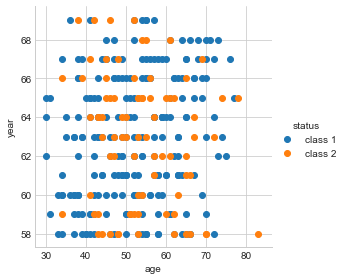

In [6]:
sns.set_style("whitegrid");
sns.FacetGrid(haberman, hue="status", size=4) \
   .map(plt.scatter, "age", "year") \
   .add_legend();
plt.show();

only "age" vs "node" plot provide some grouping
but it's hard to classify the class 1 and class 2 as both the class get overlapped

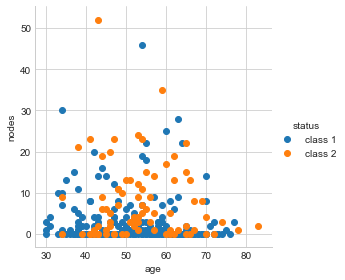

In [7]:
sns.set_style("whitegrid");
sns.FacetGrid(haberman, hue="status", size=4) \
   .map(plt.scatter, "age", "nodes") \
   .add_legend();
plt.show();

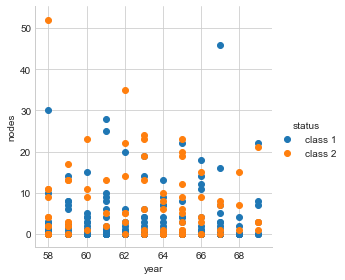

In [8]:
sns.set_style("whitegrid");
sns.FacetGrid(haberman, hue="status", size=4) \
   .map(plt.scatter, "year", "nodes") \
   .add_legend();
plt.show();

# PAIR PLOT

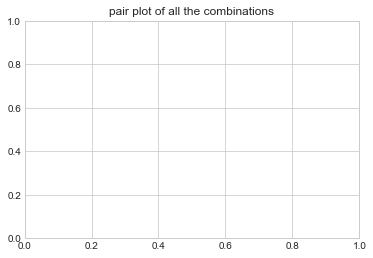

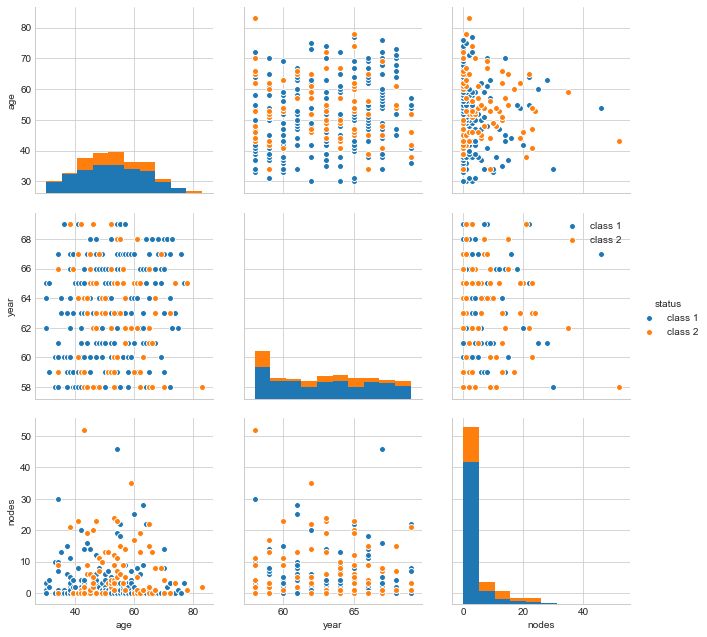

In [74]:
plt.close();
sns.set_style("whitegrid");
sns.pairplot(haberman, hue="status", size=3);

plt.legend()
plt.show()

# Observation

all both class 1 and class 2 are highly overlapped in all the cases

But the overlapping is quite low in node vs age and node vs year plot

So we may use if else to clasify the status aginst this two plottings

# UNI-VARIATE ANALYSIS

# 1d scatter  plot of nodes

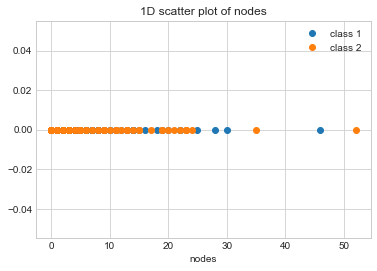

In [29]:

import numpy as np
haberman_one = haberman.loc[haberman["status"] == "class 1"];
haberman_two = haberman.loc[haberman["status"] == "class 2"];
plt.plot(haberman_one["nodes"], np.zeros_like(haberman_one['nodes']), 'o',label='class 1')
plt.plot(haberman_two["nodes"], np.zeros_like(haberman_two['nodes']), 'o',label='class 2')
plt.xlabel('nodes')
plt.title('1D scatter plot of nodes')
plt.legend()

plt.show()

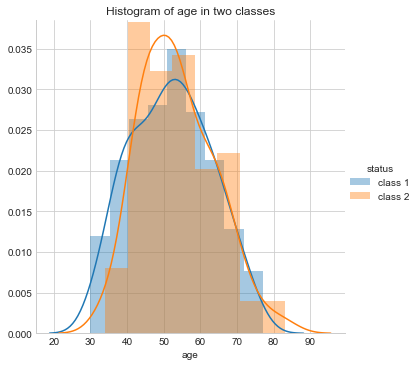

In [30]:
sns.FacetGrid(haberman, hue="status", size=5) \
   .map(sns.distplot ,"age") \
   .add_legend();
#plt.hist(normed=True)
plt.title('Histogram of age in two classes')
plt.show();

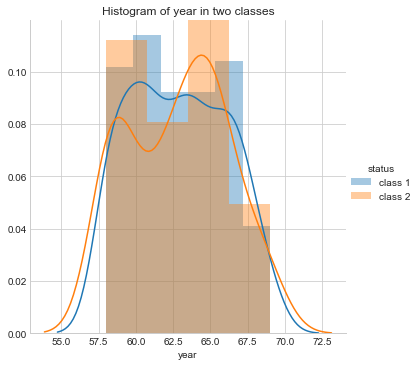

In [31]:
sns.FacetGrid(haberman, hue="status", size=5) \
   .map(sns.distplot, "year") \
   .add_legend();
plt.title('Histogram of year in two classes')
plt.show();

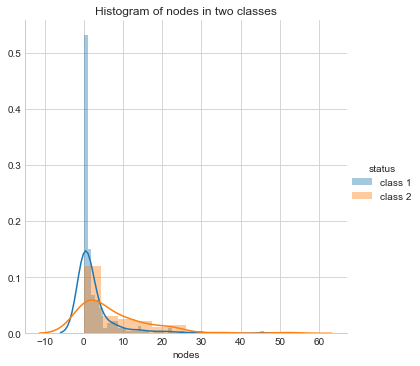

In [32]:
sns.FacetGrid(haberman, hue="status", size=5) \
   .map(sns.distplot, "nodes") \
   .add_legend();
plt.title('Histogram of nodes in two classes')
plt.show();

# Observation

so by observing all the plot we can say if the node is greater  than 30 then the probability of status 1 is very less

# PDF Plot & CDF plot

[0.83555556 0.08       0.02222222 0.02666667 0.01777778 0.00444444
 0.00888889 0.         0.         0.00444444]
[ 0.   4.6  9.2 13.8 18.4 23.  27.6 32.2 36.8 41.4 46. ]


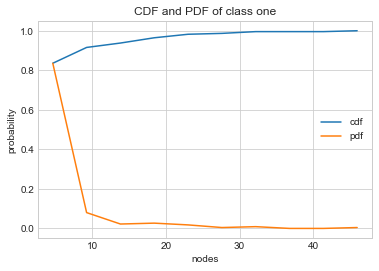

In [67]:
counts, bin_edges = np.histogram(haberman_one['nodes'], bins=10, 
                                 density = True)
pdf = counts/(sum(counts))
print(pdf);
print(bin_edges);
cdf = np.cumsum(pdf)
#plt.plot(bin_edges[1:],pdf,label='pdf');
plt.plot(bin_edges[1:], cdf,label='cdf')


counts, bin_edges = np.histogram(haberman_one['nodes'], bins=10, 
                                 density = True)
pdf = counts/(sum(counts))
plt.plot(bin_edges[1:],pdf,label='pdf');
plt.xlabel('nodes')
plt.ylabel('probability')
plt.title('CDF and PDF of class one')
plt.legend()
plt.show();

[0.83555556 0.08       0.02222222 0.02666667 0.01777778 0.00444444
 0.00888889 0.         0.         0.00444444]
[ 0.   4.6  9.2 13.8 18.4 23.  27.6 32.2 36.8 41.4 46. ]
[0.56790123 0.14814815 0.13580247 0.04938272 0.07407407 0.
 0.01234568 0.         0.         0.01234568]
[ 0.   5.2 10.4 15.6 20.8 26.  31.2 36.4 41.6 46.8 52. ]


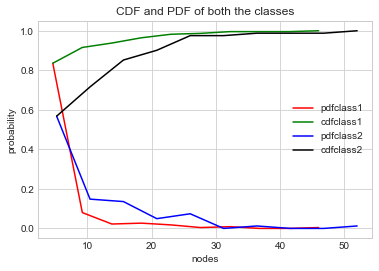

In [68]:
#class one
counts, bin_edges = np.histogram(haberman_one['nodes'], bins=10, 
                                 density = True)
pdf = counts/(sum(counts))
print(pdf);
print(bin_edges)
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:],pdf,color="red",label="pdfclass1")
plt.plot(bin_edges[1:],cdf,color="green",label="cdfclass1")


#class two
counts, bin_edges = np.histogram(haberman_two['nodes'], bins=10, 
                                 density = True)
pdf = counts/(sum(counts))
print(pdf);
print(bin_edges)
cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:],pdf,color="blue",label="pdfclass2")
plt.plot(bin_edges[1:], cdf,color="black",label="cdfclass2")
plt.title('CDF and PDF of both the classes')
plt.xlabel('nodes')
plt.ylabel('probability')
plt.legend()
plt.show()

# Observation

if the node is less than 10 there is 82 % percent chance to get ctaegorized in the class 1 and 58 % percent of chance to be in the class 2

# Mean, Std-deviation,Quantiles,90th Percentiles,Median Absolute Deviation

In [16]:

print("Means:")
print(np.mean(haberman_one["nodes"]))
print(np.mean(haberman_two["nodes"]))

print("\nStd-dev:");
print(np.std(haberman_one["nodes"]))
print(np.std(haberman_two["nodes"]))

print("\nQuantiles:")
print(np.percentile(haberman_one["nodes"],np.arange(0, 100, 25)))
print(np.percentile(haberman_two["nodes"],np.arange(0, 100, 25)))

print("\n90th Percentiles:")
print(np.percentile(haberman_one["nodes"],90))
print(np.percentile(haberman_two["nodes"],90))


from statsmodels import robust
print ("\nMedian Absolute Deviation")
print(robust.mad(haberman_one["nodes"]))
print(robust.mad(haberman_two["nodes"]))





Means:
2.7911111111111113
7.45679012345679

Std-dev:
5.857258449412131
9.128776076761632

Quantiles:
[0. 0. 0. 3.]
[ 0.  1.  4. 11.]

90th Percentiles:
8.0
20.0

Median Absolute Deviation
0.0
5.930408874022408


# BOX PLOT

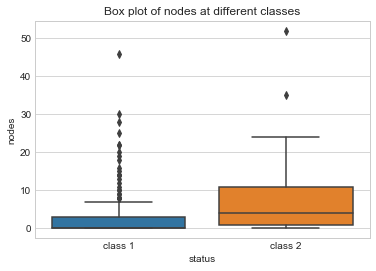

In [52]:


sns.boxplot(x='status',y='nodes', data=haberman)
plt.title('Box plot of nodes at different classes')
plt.show()


# Violin Plot

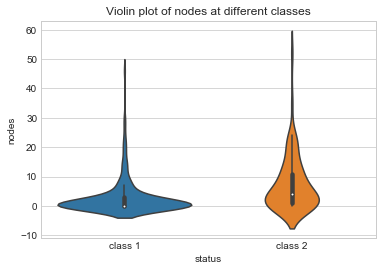

In [53]:
sns.violinplot(x="status", y="nodes", data=haberman, size=8)
plt.title('Violin plot of nodes at different classes')
plt.show()

# Multivariate probability density, contour plot

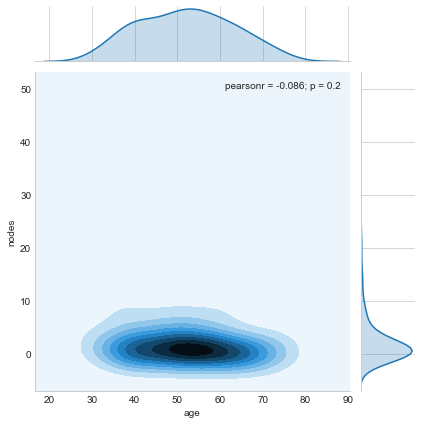

In [69]:

sns.jointplot(x="age", y="nodes", data=haberman_one, kind="kde");
#plt.title("multivariate plot of node vs age of label class 1")
plt.show();

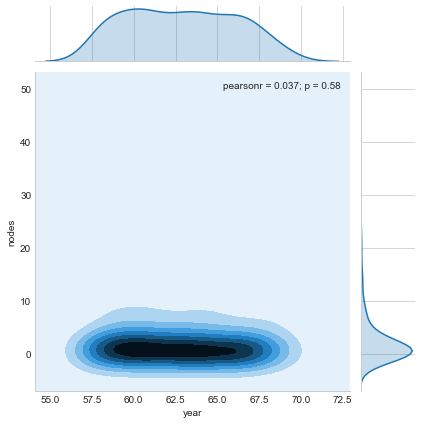

In [70]:
sns.jointplot(x="year", y="nodes", data=haberman_one, kind="kde",labels=["class 1"]);
#plt.title("multivariate plot of node vs year of label class 1 ")
plt.show()

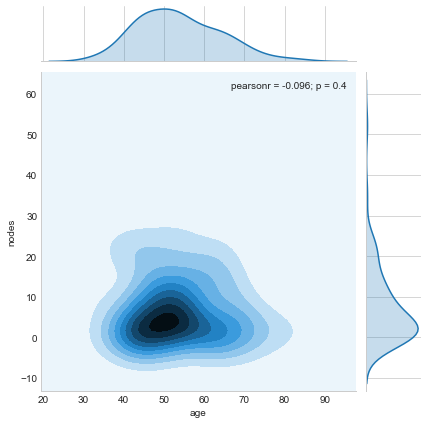

In [71]:
sns.jointplot(x="age", y="nodes", data=haberman_two, kind="kde");
#plt.title("multivariate plot of node vs age of label class 1")
plt.show();

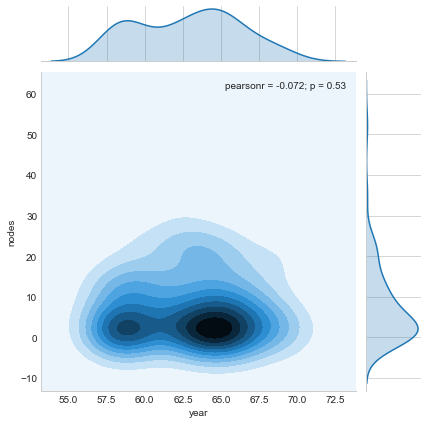

In [72]:
sns.jointplot(x="year", y="nodes", data=haberman_two, kind="kde");
#plt.title("multivariate plot of node vs year of label class 2 ")
plt.show();

# Summary of Observation

The given dataset is imbalanced as it  not contains equal no of data-points for each class.

No clear way to seperate the classes on the basis of three features

Based on "nodes" we are able to provide a simple 'if-else-=' model to distinguish the  classes but it  works for eithtier large no of data-point or very small no of data-point.

From Box  Violin plot, the class 1 is more dense in terms of nodes. 
Most of people who survived had 1-10 nodes.

Class 2 is more spreaded and the dead patients had nodes over a wide range